## 1. Carga de librerías

In [74]:
import pandas as pd


## 2. Carga de datasets

In [75]:


mortalidad = pd.read_csv(
    "../data/raw/data_INE_DemografiaEmpresarial_mortalidad_empresas_primeros_anos.csv",
    sep=";",
    decimal=","
)

empresas_sector_nuevos = pd.read_excel(
    "../data/raw/data_INE_DIRCE_empresas_activas_por_sector_CNAE_nuevo.xlsx",
    header=8
)

empresas_sector_antiguo = pd.read_excel(
    "../data/raw/data_INE_DIRCE_empresas_activas_por_sector_CNAE_antiguo.xlsx",
    header=8
)

paro = pd.read_excel(
    "../data/raw/data_INE_EPA_tasa_paro.xlsx",
    header=5 
)

concursos_nuevo = pd.read_excel(
    "../data/raw/data_rawINE_concursos_empresas_sector_nuevo.xlsx"
)

concursos_antiguo = pd.read_excel(
    "../data/raw/data_rawINE_concursos_empresas_sector_antiguo.xlsx"
)

coste_laboral = pd.read_excel(
    "../data/raw/data_rawINE_coste_laboral_sector_trimestral.xlsx"
)

pib = pd.read_excel(
    "../data/raw/data_rawINE_MacroPIB_tasas_variacion_espana.xlsx"
)

morosidad_finalidad = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_finalidad_gasto.xlsx"
)

morosidad_sector = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_por_actividad.xlsx"
)

rentabilidad = pd.read_excel(
    "../data/raw/data_rawBancoEspana_rentabilidad_empresas.xlsx"
)


condicion_juridica = pd.read_excel(
    "../data/raw/data_rawEmpresas_condicion_juridica.xls"
)

estrato_asalariados_nuevo = pd.read_excel(
    "../data/raw/data_rawEmpresas_estrato_asalariados_nuevo.xlsx"
)

estrato_asalariados_antiguo = pd.read_excel(
    "../data/raw/data_rawEmpresas_estrato_asalariados_antiguo.xlsx"
)

euribor = pd.read_csv(
    "../data/raw/data_rawEuribor.csv",
    sep=";",
    encoding="latin1"
)


c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl'

## 3. Limpieza y transformación

# LIMPIEZA DATASET MORTALIDAD INE
Limpieza y preparación del dataset de mortalidad empresarial mediante normalización de columnas, eliminación de filas no válidas y conversión a formato numérico.
Obtención de un dataset estructurado y listo para su integración con otras fuentes en el modelo de análisis de quiebras.


In [76]:

mortalidad.columns = mortalidad.columns.str.strip()

mortalidad = mortalidad.rename(columns={
    "Cohortes": "year",
    "Año 1 de vida": "year_1",
    "Año 2 de vida": "year_2",
    "Año 3 de vida": "year_3",
    "Acumulado": "accumulated"
})

# 3. ELIMINAR FILAS NO VÁLIDAS
mortalidad = mortalidad[mortalidad["year"] != "Promedio"]


# 4. CONVERSIÓN DE TIPOS
mortalidad["year"] = mortalidad["year"].astype(int)

cols_numeric = ["year_1", "year_2", "year_3", "accumulated"]

for col in cols_numeric:
    mortalidad[col] = pd.to_numeric(mortalidad[col], errors="coerce")


# 5. ORDENAR DATOS
mortalidad = mortalidad.sort_values("year").reset_index(drop=True)


# 6. FEATURE ENGINEERING
# Variación interanual del acumulado
mortalidad["accumulated_growth"] = mortalidad["accumulated"].pct_change()

# Diferencias entre años de vida
mortalidad["diff_1_2"] = mortalidad["year_2"] - mortalidad["year_1"]
mortalidad["diff_2_3"] = mortalidad["year_3"] - mortalidad["year_2"]


# 7. DATASET PARA MODELADO
# Eliminamos filas con missing para modelos predictivos
mortalidad_model = mortalidad.dropna()


# 8. OPCIONAL: FORMATO LARGO
mortalidad_long = mortalidad.melt(
    id_vars="year",
    value_vars=["year_1", "year_2", "year_3"],
    var_name="life_year",
    value_name="mortality_rate"
)

# 9. GUARDADO
mortalidad.to_csv("../data/processed/mortalidad_clean.csv", index=False)



C:\Users\tatia\AppData\Local\Temp\ipykernel_25216\3698637527.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  mortalidad["accumulated_growth"] = mortalidad["accumulated"].pct_change()


# LIMPIEZA DATASETS EMPRESAS ACTIVAS

Se han limpiado, transformado y unificado dos datasets del INE sobre empresas activas por sector CNAE, filtrando el sector servicios y agregando la información a nivel de dos dígitos.
El resultado es un dataset estructurado y consistente, preparado para su integración en el modelo de análisis de quiebras.

In [77]:


# FUNCIÓN LIMPIEZA 
def clean_dirce(file_path, year_cols):
    
    df = pd.read_excel(file_path)
    
    # Quitar cabeceras basura
    df = df.iloc[8:]
    
    # Renombrar columnas
    df.columns = ["sector"] + year_cols
    
    # Eliminar filas vacías
    df = df.dropna(subset=["sector"])
    
    # Extraer CNAE (2 dígitos)
    df["cnae_code"] = df["sector"].str.extract(r"(\d{2})")
    df["cnae_code"] = pd.to_numeric(df["cnae_code"], errors="coerce")
    
    # Filtrar solo servicios
    df = df[(df["cnae_code"] >= 45) & (df["cnae_code"] <= 96)]
    
    # Agrupar por CNAE
    df = df.groupby("cnae_code").sum(numeric_only=True).reset_index()
    
    # Pasar a formato largo
    df = df.melt(
        id_vars="cnae_code",
        var_name="year",
        value_name="num_companies"
    )
    
    df["year"] = df["year"].astype(int)
    
    return df


# 1. LIMPIAR DATASET ANTIGUO
df_old = clean_dirce(
    "../data/raw/data_INE_DIRCE_empresas_activas_por_sector_CNAE_antiguo.xlsx",
    ["2020","2019","2018","2017","2016","2015","2014","2013","2012","2011"]
)


# 2. LIMPIAR DATASET NUEVO
df_new = clean_dirce(
    "../data/raw/data_INE_DIRCE_empresas_activas_por_sector_CNAE_nuevo.xlsx",
    ["2025","2024","2023","2022","2021","2020"]
)


# 3. UNIR DATASETS
df_all = pd.concat([df_old, df_new])


# 4. ELIMINAR DUPLICADOS (2020)
df_all = df_all.drop_duplicates(subset=["cnae_code", "year"])


# 5. ORDENAR
df_all = df_all.sort_values(["cnae_code", "year"]).reset_index(drop=True)


# 6. DICCIONARIO CNAE 
cnae_dict = {
    45: "Venta y reparación de vehículos",
    46: "Comercio al por mayor",
    47: "Comercio al por menor",
    49: "Transporte terrestre",
    50: "Transporte marítimo",
    51: "Transporte aéreo",
    52: "Almacenamiento y logística",
    53: "Actividades postales",
    55: "Alojamiento",
    56: "Restauración",
    58: "Edición",
    59: "Audiovisual",
    60: "Radio y televisión",
    61: "Telecomunicaciones",
    62: "Programación informática",
    63: "Servicios de información",
    64: "Servicios financieros",
    65: "Seguros",
    66: "Actividades auxiliares financieras",
    68: "Actividades inmobiliarias",
    69: "Servicios jurídicos y contabilidad",
    70: "Consultoría empresarial",
    71: "Arquitectura e ingeniería",
    72: "I+D",
    73: "Publicidad y estudios de mercado",
    74: "Actividades profesionales",
    75: "Veterinaria",
    77: "Alquiler",
    78: "Empleo",
    79: "Agencias de viajes",
    80: "Seguridad",
    81: "Servicios a edificios",
    82: "Servicios administrativos",
    85: "Educación",
    86: "Sanidad",
    87: "Servicios sociales con alojamiento",
    88: "Servicios sociales sin alojamiento",
    90: "Actividades artísticas",
    91: "Cultura",
    92: "Juego y apuestas",
    93: "Deporte y ocio",
    94: "Asociaciones",
    95: "Reparaciones",
    96: "Otros servicios personales"
}

# Añadir nombre del sector
df_all["sector_name"] = df_all["cnae_code"].map(cnae_dict)

# (opcional) quitar nulos
df_all = df_all.dropna(subset=["sector_name"])


# 7. GUARDAR
df_all.to_csv("../data/processed/empresas_servicios_clean.csv", index=False)



c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# LIMPIEZA DATASET PARO

Se ha transformado el dataset eliminando cabeceras no estructuradas y columnas duplicadas, seleccionando únicamente la tasa de paro total nacional.
Se obtiene un dataset en formato year–unemployment_rate, limpio, sin duplicados y alineado temporalmente con el resto de variables.

In [78]:

# 1. CARGA SIN HEADER
paro = pd.read_excel(
    "../data/raw/data_INE_EPA_tasa_paro.xlsx",
    header=None
)

# 2. LIMPIAR STRINGS
paro = paro.astype(str).apply(lambda x: x.str.strip())


# 3. EXTRAER FILAS CLAVE
# Fila donde están los años
years_row = paro.iloc[7]
# Buscar fila que contiene "Total Nacional"
mask = paro.apply(
    lambda row: row.astype(str).str.contains("Total Nacional", case=False).any(),
    axis=1
)

data_row = paro[mask].index[0]
values_row = paro.iloc[data_row]


# 4. CONSTRUIR DATASET
years = pd.to_numeric(years_row, errors="coerce")
values = pd.to_numeric(values_row, errors="coerce")

df_paro = pd.DataFrame({
    "year": years,
    "unemployment_rate": values
})


# 5. LIMPIEZA
# eliminar columnas basura
df_paro = df_paro.dropna()

# eliminar duplicados → quedarse con 1 valor por año
df_paro = df_paro.groupby("year", as_index=False)["unemployment_rate"].first()

# ordenar
df_paro = df_paro.sort_values("year")
df_paro = df_paro[df_paro["year"] >= 2011]

# 6. GUARDAR
df_paro.to_csv("../data/processed/paro_clean.csv", index=False)





c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# LIMPIEZA DATASET CREDITOS DUDOSOS

Se ha transformado el dataset eliminando metadatos y seleccionando la serie de créditos dudosos de actividades productivas, convirtiéndola a formato numérico.
Los datos mensuales se han agregado a nivel anual, obteniendo una serie temporal limpia y consistente para el modelo.

In [79]:

# 1. CARGA DEL DATASET
df = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_finalidad_gasto.xlsx",
    header=None
)

# 2. RENOMBRAR COLUMNAS
df = df.rename(columns={0: "date"})

# 3. ELIMINAR FILAS METADATA
df = df.iloc[6:]  # aquí empiezan las fechas

# 4. LIMPIAR FECHA
df = df[df["date"].str.contains(r"\d{4}", na=False)]

# 5. IDENTIFICAR COLUMNA CORRECTA

# usamos fila 3 como referencia de nombres
col_names = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_finalidad_gasto.xlsx",
    header=None
).iloc[3]

target_idx = [
    i for i, col in enumerate(col_names)
    if "dudosos" in str(col).lower()
    and "productivas" in str(col).lower()
][0]

# 6. SELECCIONAR VARIABLE
df = df[["date", target_idx]]
df = df.rename(columns={target_idx: "bad_loans"})

# 7. LIMPIAR DATOS
df["bad_loans"] = pd.to_numeric(df["bad_loans"], errors="coerce")
df = df.dropna()

# 8. EXTRAER AÑO
df["year"] = df["date"].str.extract(r"(\d{4})").astype(int)

# 9. PASAR A ANUAL
df = df.groupby("year", as_index=False)["bad_loans"].mean()

df["bad_loans_growth"] = df["bad_loans"].pct_change()
df = df.dropna()

# 10. FILTRAR
df = df[df["year"] >= 2011]
df.to_csv("../data/processed/morosidad_finalidad_clean.csv", index=False)


# LIMPIEZA DATASET MOROSIDAD POR ACTIVIDAD

Se ha seleccionado la serie de créditos dudosos del sector servicios, eliminando metadatos y variables no relevantes, y transformando los datos mensuales a frecuencia anual.
Se ha añadido la variación interanual como variable derivada, obteniendo una serie temporal limpia y alineada con el modelo.

In [80]:

# Cargar dataset sin cabecera 
df = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_por_actividad.xlsx",
    header=None
)

# Renombrar primera columna como fecha
df = df.rename(columns={0: "date"})

# Eliminar filas de metadatos (dejamos solo las fechas)
df = df.iloc[6:]

# Quedarnos solo con filas que contienen un año (fechas reales)
df = df[df["date"].str.contains(r"\d{4}", na=False)]

# Leer nombres de las series (están en otra fila del Excel)
col_names = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_por_actividad.xlsx",
    header=None
).iloc[3]

# Identificar la columna de interés:
# Créditos dudosos + servicios + total
target_idx = [
    i for i, col in enumerate(col_names)
    if "dudosos" in str(col).lower()
    and "servicios" in str(col).lower()
    and "total" in str(col).lower()
][0]

# Seleccionar solo fecha y variable relevante
df = df[["date", target_idx]]

# Renombrar variable
df = df.rename(columns={target_idx: "bad_loans_services"})

# Convertir a numérico y eliminar valores nulos
df["bad_loans_services"] = pd.to_numeric(df["bad_loans_services"], errors="coerce")
df = df.dropna()

# Extraer año de la fecha
df["year"] = df["date"].str.extract(r"(\d{4})").astype(int)

# Agregar de mensual a anual (media)
df = df.groupby("year", as_index=False)["bad_loans_services"].mean()

# Crear variable de crecimiento (muy útil para el modelo)
df["bad_loans_services_growth"] = df["bad_loans_services"].pct_change()

# Eliminar primera fila (NaN del growth)
df = df.dropna()

# Filtrar años (coherente con resto de datasets)
df = df[df["year"] >= 2011]

# Guardar dataset limpio
df.to_csv("../data/processed/morosidad_servicios_clean.csv", index=False)


# LIMPIEZA DATASET DE RENTABILIDAD EMPRESAS

Se ha cargado el dataset con header=None, eliminando filas no informativas y seleccionando la columna correspondiente a la rentabilidad del sector comercio y hostelería (año actual). Se han tipado las variables y filtrado el rango temporal desde 2011.

In [81]:
import pandas as pd

# Cargar dataset sin cabecera (estructura tipo Banco de España)
df = pd.read_excel(
    "../data/raw/data_rawBancoEspana_rentabilidad_empresas.xlsx",
    header=None
)

# Renombrar primera columna como año
df = df.rename(columns={0: "year"})

# Eliminar filas de metadatos (nos quedamos con datos reales)
df = df.iloc[6:]

# Filtrar solo filas que contienen años
df = df[df["year"].astype(str).str.contains(r"\d{4}", na=False)]

# Obtener nombres de columnas (están en otra fila del Excel)
col_names = pd.read_excel(
    "../data/raw/data_rawBancoEspana_rentabilidad_empresas.xlsx",
    header=None
).iloc[3]

# Seleccionar columna: rentabilidad comercio y hostelería (año actual)
target_idx = [
    i for i, col in enumerate(col_names)
    if "comercio" in str(col).lower()
    and "hostelería" in str(col).lower()
    and "año actual" in str(col).lower()
][0]

# Seleccionar variables
df = df[["year", target_idx]]
df = df.rename(columns={target_idx: "profitability"})

# Convertir a numérico
df["profitability"] = pd.to_numeric(df["profitability"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Eliminar nulos
df = df.dropna()

# Filtrar rango temporal
df = df[df["year"] >= 2011]

# Ordenar
df = df.sort_values("year")
df.to_csv("../data/processed/rentabilidad_clean.csv", index=False)


# LIMPIEZA DATSET CONDICION JURIDICA

Se han seleccionado las columnas de personas físicas y sociedades limitadas, calculando ratios sobre el total de empresas.
Se obtiene una serie anual limpia que refleja la estructura del tejido empresarial.

In [82]:
df = pd.read_excel(
    "../data/raw/data_rawEmpresas_condicion_juridica.xls",
    skiprows=10,
    header=None
)

# Seleccionar columnas correctas según tu print
df = df.rename(columns={
    1: "year",
    2: "total_companies",
    6: "self_employed",
    11: "limited_companies"
})

# Quedarnos solo con esas columnas
df = df[["year", "total_companies", "self_employed", "limited_companies"]]

# Convertir a numérico
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar filas sin año
df = df.dropna(subset=["year"])

# Crear ratios
df["ratio_self_employed"] = df["self_employed"] / df["total_companies"]
df["ratio_limited"] = df["limited_companies"] / df["total_companies"]

# Filtrar años
df = df[df["year"] >= 2011]

# Dataset final
df = df[["year", "ratio_self_employed", "ratio_limited"]]

df.to_csv("../data/processed/condicion_juridica_clean.csv", index=False)


# LIMPIEZA DATSET ESTRACTO DE ASALARIADOS

Se integraron dos datasets del INE con distinta cobertura temporal, normalizando su estructura y eliminando duplicidades.
Los datos fueron transformados a formato analítico y agregados para obtener las principales magnitudes del tejido empresarial.
Finalmente, se construyeron ratios clave que permiten analizar la composición empresarial y su relación con la vulnerabilidad económica.

In [83]:

def limpiar_forma_juridica(path, tipo_columna):

    # Leer Excel con multiindex
    df = pd.read_excel(path, skiprows=6, header=[0,1])

    # Limpiar nombres columnas
    df.columns = [(str(c0).strip(), str(c1).strip()) for c0, c1 in df.columns]

    # Renombrar columna de estratos
    df = df.rename(columns={df.columns[0]: "size"})
    df["size"] = df["size"].astype(str).str.strip()

    # Eliminar filas vacías
    df = df.dropna(subset=["size"])

    # Normalizador robusto
    def _norm(s):
        return str(s).strip().lower()

    # Detectar columnas de la variable (Total, SL, etc.)
    cols = [col for col in df.columns if _norm(col[0]) == _norm(tipo_columna)]

    if len(cols) == 0:
        raise ValueError(f"❌ No se encontró la columna {tipo_columna} en {path}")

    # Subset y copia segura
    df_tipo = df.loc[:, cols].copy()

    # Aplanar columnas → años
    df_tipo.columns = [col[1] for col in cols]

    # Añadir size
    df_tipo = df_tipo.assign(size=df["size"])

    # Formato largo
    df_tipo = df_tipo.melt(
        id_vars="size",
        var_name="year",
        value_name=tipo_columna
    )

    # Tipos
    df_tipo["year"] = pd.to_numeric(df_tipo["year"], errors="coerce")
    df_tipo[tipo_columna] = pd.to_numeric(df_tipo[tipo_columna], errors="coerce")

    df_tipo = df_tipo.dropna()
    df_tipo = df_tipo[df_tipo["year"] >= 2011]

    return df_tipo


# RUTAS
path_new = "../data/raw/data_rawEmpresas_estrato_asalariados_nuevo.xlsx"
path_old = "../data/raw/data_rawEmpresas_estrato_asalariados_antiguo.xlsx"


# FUNCIÓN UNIÓN 
def cargar_variable(tipo):

    df_new = limpiar_forma_juridica(path_new, tipo)
    df_old = limpiar_forma_juridica(path_old, tipo)

    # Unir con flag de origen
    df = pd.concat([df_old.assign(_src=0), df_new.assign(_src=1)])

    # Ordenar y eliminar duplicados (nos quedamos con el nuevo)
    df = df.sort_values(["size", "year", "_src"]).drop_duplicates(
        subset=["size", "year"], keep="last"
    ).drop(columns="_src")

    return df


# CARGAR VARIABLES
df_total = cargar_variable("Total")
df_autonomos = cargar_variable("Personas físicas")
df_sl = cargar_variable("Sociedades de responsabilidad limitada")


# AGREGAR POR AÑO
total = df_total.groupby("year")["Total"].sum().reset_index()
total = total.rename(columns={"Total": "total_companies"})

autonomos = df_autonomos.groupby("year")["Personas físicas"].sum().reset_index()
autonomos = autonomos.rename(columns={"Personas físicas": "autonomos"})

sl = df_sl.groupby("year")["Sociedades de responsabilidad limitada"].sum().reset_index()
sl = sl.rename(columns={"Sociedades de responsabilidad limitada": "sl_companies"})


# EMPRESAS PEQUEÑAS
small = df_total[
    df_total["size"].str.contains("sin asalariados|1 a 2|3 a 5|6 a 9", case=False)
]

small = small.groupby("year")["Total"].sum().reset_index()
small = small.rename(columns={"Total": "small_companies"})


# MERGE FINAL
df_final = total.merge(small, on="year", validate="one_to_one") \
                .merge(autonomos, on="year", validate="one_to_one") \
                .merge(sl, on="year", validate="one_to_one")


# VARIABLES DERIVADAS
df_final["ratio_pyme_empleadoras"] = df_final["small_companies"] / df_final["total_companies"]
df_final["ratio_autonomos"] = df_final["autonomos"] / df_final["total_companies"]
df_final["ratio_sl"] = df_final["sl_companies"] / df_final["total_companies"]


# FORMATO FINAL
df_final["total_companies"] = df_final["total_companies"].astype(int)
df_final["small_companies"] = df_final["small_companies"].astype(int)
df_final["autonomos"] = df_final["autonomos"].astype(int)
df_final["sl_companies"] = df_final["sl_companies"].astype(int)

df_final["ratio_pyme_empleadoras"] = df_final["ratio_pyme_empleadoras"].round(4)
df_final["ratio_autonomos"] = df_final["ratio_autonomos"].round(4)
df_final["ratio_sl"] = df_final["ratio_sl"].round(4)


# ORDEN Y GUARDADO
df_final = df_final.sort_values("year")
df_final.to_csv("../data/processed/estructura_empresarial_final.csv", index=False)

c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl'

# LIMPIEZA EURIBOR

Se limpió un dataset complejo del Banco de España eliminando metadatos, corrigiendo su estructura y seleccionando la serie de Euribor.
Los datos diarios se transformaron y agregaron a nivel anual para garantizar su compatibilidad con el resto del análisis.
Finalmente, se generaron variables derivadas que capturan la evolución del Euribor, mejorando su utilidad en el modelo predictivo.

In [84]:

import numpy as np


euribor = pd.read_csv(
    "../data/raw/data_rawEuribor.csv",
    sep=",",
    encoding="latin1"
)

# LIMPIAR COLUMNAS
euribor.columns = euribor.columns.str.strip()
euribor = euribor.iloc[5:]

# RENOMBRAR FECHA
euribor = euribor.rename(columns={euribor.columns[0]: "date"})

# PARSEAR FECHAS
euribor["date"] = pd.to_datetime(euribor["date"], errors="coerce")

# SELECCIONAR COLUMNA EURIBOR 
euribor_value_col = euribor.columns[8]

euribor = euribor[["date", euribor_value_col]]
euribor = euribor.rename(columns={euribor_value_col: "euribor"})

# LIMPIAR VALORES
euribor["euribor"] = euribor["euribor"].replace("_", None)
euribor["euribor"] = pd.to_numeric(euribor["euribor"], errors="coerce")

euribor = euribor.dropna()

# CREAR AÑO
euribor["year"] = euribor["date"].dt.year

# AGREGAR A NIVEL ANUAL
euribor_year = euribor.groupby("year")["euribor"].mean().reset_index()

# FILTRAR AÑOS DEL TFG
euribor_year = euribor_year[
    (euribor_year["year"] >= 2011) &
    (euribor_year["year"] <= 2025)
]

# REDONDEAR
euribor_year["euribor"] = euribor_year["euribor"].round(4)

# VARIABLE CAMBIO (ROBUSTA)
euribor_year["euribor_change"] = euribor_year["euribor"].diff().fillna(0)
euribor_year["euribor_change"] = euribor_year["euribor_change"].round(4)

# VARIABLE PRO (LOG CHANGE)
euribor_year["euribor_log_change"] = (
    np.log(euribor_year["euribor"] + 1) - np.log(euribor_year["euribor"].shift(1) + 1)
)
euribor_year["euribor_log_change"] = euribor_year["euribor_log_change"].fillna(0).round(4)

# ORDENAR
euribor_year = euribor_year.sort_values("year")
euribor_year.to_csv("../data/processed/euribor_clean.csv", index=False)


C:\Users\tatia\AppData\Local\Temp\ipykernel_25216\1565779773.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  euribor["date"] = pd.to_datetime(euribor["date"], errors="coerce")


# LIMPIEZA DATASET COSTE LABORAL

Se limpió y transformó el dataset de coste laboral del INE corrigiendo su estructura y formato numérico.
Se filtró el sector servicios y se agregaron los datos trimestrales a nivel anual para garantizar coherencia con el modelo.
Finalmente, se generó una variable de variación anual que permite analizar la presión de costes sobre las empresas.

In [85]:
# LEER EXCEL CON HEADER CORRECTO
coste_laboral = pd.read_excel(
    "../data/raw/data_rawINE_coste_laboral_sector_trimestral.xlsx",
    header=7  
)

# RENOMBRAR PRIMERA COLUMNA
coste_laboral = coste_laboral.rename(columns={coste_laboral.columns[0]: "sector"})

# LIMPIAR TEXTO
coste_laboral["sector"] = coste_laboral["sector"].astype(str).str.strip()

# FILTRAR SERVICIOS
coste_servicios = coste_laboral[
    coste_laboral["sector"].str.lower() == "servicios"
]

# ELIMINAR COLUMNA sector
coste_servicios = coste_servicios.drop(columns=["sector"])

# PASAR A FORMATO LARGO
coste_servicios = coste_servicios.melt(
    var_name="period",
    value_name="coste_laboral"
)

# LIMPIAR VALORES
coste_servicios["coste_laboral"] = (
    coste_servicios["coste_laboral"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

coste_servicios["coste_laboral"] = pd.to_numeric(
    coste_servicios["coste_laboral"], errors="coerce"
)

coste_servicios = coste_servicios.dropna()

# EXTRAER AÑO
coste_servicios["year"] = coste_servicios["period"].str[:4].astype(int)

# AGREGAR ANUAL
coste_anual = coste_servicios.groupby("year")["coste_laboral"].mean().reset_index()

# FILTRAR AÑOS
coste_anual = coste_anual[
    (coste_anual["year"] >= 2011) &
    (coste_anual["year"] <= 2025)
]

# REDONDEAR
coste_anual["coste_laboral"] = coste_anual["coste_laboral"].round(2)

# CAMBIO
coste_anual["coste_laboral_change"] = (
    coste_anual["coste_laboral"].diff().fillna(0).round(2)
)

coste_anual.to_csv(
    "../data/processed/coste_laboral_clean.csv",
    index=False
)


c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# LIMPIEZA DATASET DEL PIB

Se limpió un dataset del PIB con estructura no tabular mediante detección automática de filas relevantes y normalización de columnas.
Se extrajeron los años correctamente, eliminando anotaciones y transformando los datos a formato largo.
Finalmente, se generó una serie anual coherente con una variable de variación interanual lista para el análisis.

In [87]:
import pandas as pd

# LEER SIN HEADER
pib_raw = pd.read_excel(
    "../data/raw/data_rawINE_MacroPIB_tasas_variacion_espana.xlsx",
    header=None
)

# BUSCAR FILA PIB REAL
fila_pib = None
for i in range(len(pib_raw)):
    fila = pib_raw.iloc[i].astype(str).str.upper()
    if any("PRODUCTO INTERIOR BRUTO" in cell for cell in fila):
        valores = pd.to_numeric(pib_raw.iloc[i], errors="coerce")
        if valores.notna().sum() > 5:
            fila_pib = i
            break


# BUSCAR FILA AÑOS
fila_years = None
for i in range(len(pib_raw)):
    fila = pib_raw.iloc[i].astype(str)
    if any("2011" in cell for cell in fila):
        fila_years = i
        break


# EXTRAER
pib = pib_raw.iloc[fila_pib].to_frame().T
years = pib_raw.iloc[fila_years]

# ASIGNAR COLUMNAS
pib.columns = years

#LIMPIAR NOMBRES DE COLUMNAS
nuevas_cols = []
for col in pib.columns:
    col_str = str(col)
    
    # extraer solo los 4 primeros dígitos si existen
    year = ''.join([c for c in col_str if c.isdigit()])
    
    if len(year) >= 4:
        nuevas_cols.append(int(year[:4]))
    else:
        nuevas_cols.append(None)

pib.columns = nuevas_cols

# ELIMINAR COLUMNAS SIN AÑO
pib = pib.loc[:, pib.columns.notna()]

# FORMATO LARGO
pib = pib.melt(
    var_name="year",
    value_name="pib_growth"
)

# LIMPIAR
pib["year"] = pd.to_numeric(pib["year"], errors="coerce")
pib["pib_growth"] = pd.to_numeric(pib["pib_growth"], errors="coerce")

pib = pib.dropna()

# FILTRAR
pib = pib[
    (pib["year"] >= 2011) &
    (pib["year"] <= 2024)
]

# REDONDEAR
pib["pib_growth"] = pib["pib_growth"].round(2)

# CAMBIO
pib["pib_change"] = pib["pib_growth"].diff().fillna(0).round(2)

# ORDENAR
pib = pib.sort_values("year")
pib.to_csv("../data/processed/pib_clean.csv", index=False)


# LIMPIEZA DATASET CONCURSOS

In [106]:

df = pd.read_excel(
    "../data/raw/data_rawINE_concursos_empresas_sector_antiguo.xlsx",
    header=None
)

# ENCONTRAR FILA DE AÑOS
fila_years = None

for i in range(len(df)):
    row = df.iloc[i].astype(str)
    if row.str.contains("2011").any():
        fila_years = i
        break


# EXTRAER AÑOS (POR POSICIÓN)
years = df.iloc[fila_years].dropna().values

# FILTRAR SOLO AÑOS
years = [int(str(y)[:4]) for y in years if str(y)[:4].isdigit()]

# DATA
data = df.iloc[fila_years + 2:].copy()

# PRIMERA COLUMNA = sector
data = data.rename(columns={data.columns[0]: "sector"})

#COGER COLUMNAS POR POSICIÓN 
data = data.iloc[:, :len(years)+1]

# ASIGNAR NOMBRES
data.columns = ["sector"] + years

data = data.dropna(subset=["sector"])

# LIMPIAR VALORES
for col in years:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna()

total_antiguo = data[years].sum().reset_index()
total_antiguo.columns = ["year", "concursos"]

total_antiguo["year"] = total_antiguo["year"].astype(int)
total_antiguo = total_antiguo[
    (total_antiguo["year"] >= 2011) &
    (total_antiguo["year"] <= 2020)
]
total_antiguo = total_antiguo.sort_values("year")
total_antiguo["concursos_change"] = total_antiguo["concursos"].diff().fillna(0)


# -------------------- LIMPIEZA CONCURSOS DEL 2021 A 2025 -------------------------------------------
df = pd.read_excel(
    "../data/raw/data_rawINE_concursos_empresas_sector_nuevo.xlsx",
    header=6
)


# LIMPIAR NOMBRES
df = df.rename(columns={df.columns[0]: "sector"})
df["sector"] = df["sector"].astype(str).str.strip()

# QUEDARSE SOLO CON COLUMNAS DE DATOS
# eliminar columnas tipo "España"
cols_validas = ["sector"]

for col in df.columns:
    if "202" in str(col):  # detecta columnas tipo 2021/I
        cols_validas.append(col)

df = df[cols_validas]

# LIMPIAR VALORES
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

total_nuevo = df.iloc[:, 1:].sum().reset_index()
total_nuevo.columns = ["period", "concursos"]

total_nuevo["year"] = total_nuevo["period"].str.extract(r"(\d{4})").astype(int)

total_nuevo = total_nuevo.groupby("year")["concursos"].sum().reset_index()
total_nuevo = total_nuevo.sort_values("year")
total_nuevo["concursos_change"] = total_nuevo["concursos"].diff().fillna(0)


# ------------------------------------- UNIÓN FINAL ----------------------------------

concursos_total = pd.concat([total_antiguo, total_nuevo])

concursos_total = concursos_total.drop_duplicates(subset=["year"])
concursos_total = concursos_total.sort_values("year")
concursos_total = concursos_total.reset_index(drop=True)

concursos_total.to_csv("../data/processed/concursos_total.csv", index=False)




c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# 4. CONSTRUCCIÓN DATASET FINAL

In [109]:

concursos = pd.read_csv("../data/processed/concursos_total.csv")
euribor = pd.read_csv("../data/processed/euribor_clean.csv")
pib = pd.read_csv("../data/processed/pib_clean.csv")
coste = pd.read_csv("../data/processed/coste_laboral_clean.csv")
estructura = pd.read_csv("../data/processed/estructura_empresarial_final.csv")
paro = pd.read_csv("../data/processed/paro_clean.csv")
morosidad = pd.read_csv("../data/processed/morosidad_clean.csv")
rentabilidad = pd.read_csv("../data/processed/rentabilidad_clean.csv")

# BASE

df = concursos.copy()

# MERGES

dfs = [
    euribor,
    pib,
    coste,
    estructura,
    paro,
    morosidad,
    rentabilidad
]

for d in dfs:
    df = df.merge(d, on="year", how="left")

# LIMPIAR DUPLICADOS DE COLUMNAS

df = df.loc[:, ~df.columns.duplicated()]

# ORDEN

df = df.sort_values("year")

# TARGET

df["target"] = (df["concursos_change"] > 0).astype(int)

df = df.fillna(method="ffill")

# DATASET MODELO

df_model = df.drop(columns=["concursos_change"])

columns_to_keep = [
    "year",
    "concursos",
    "target",
    "euribor",
    "pib_growth",
    "unemployment_rate",
    "coste_laboral",
    "ratio_pyme_empleadoras",
    "bad_loans",
    "profitability"
]

df_model = df_model[columns_to_keep]


df_model.to_csv("../data/processed/final_dataset.csv", index=False)

C:\Users\tatia\AppData\Local\Temp\ipykernel_25216\1031964609.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


# 5. VALIDACIÓN Y ANALISIS

## EVOLUCIÓN TEMPORAL

### Se observa un máximo en el número de concursos en el periodo 2012–2013, coincidiendo con los efectos de la crisis financiera. Posteriormente, se produce una tendencia descendente asociada a la recuperación económica, con un leve repunte en los últimos años

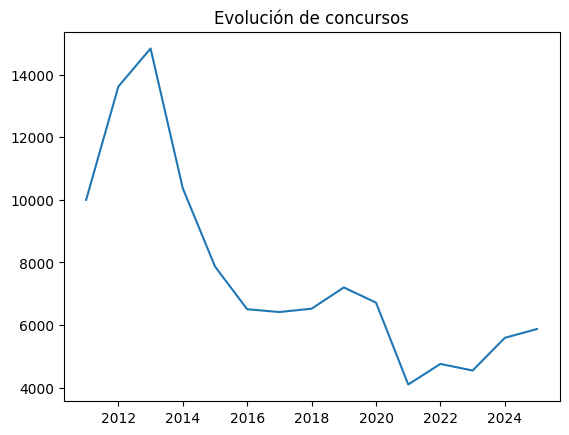

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_model["year"], df_model["concursos"])
plt.title("Evolución de concursos")
plt.show()

## MATRIZ DE CORRELACIONES ENTRE VARIABLES EXPLICATIVAS

### El análisis de correlaciones muestra la existencia de relaciones significativas entre varias variables explicativas, lo que sugiere la presencia de multicolinealidad en el conjunto de datos. En particular, se observa una alta correlación positiva entre la tasa de desempleo y la morosidad (0.98), así como entre el Euribor y el coste laboral (0.92), lo que indica que estas variables podrían estar capturando dinámicas económicas similares. Asimismo, el número de concursos presenta una fuerte relación positiva con el desempleo (0.87) y la morosidad (0.85), y una relación negativa con el crecimiento del PIB (-0.61) y la rentabilidad (-0.70), lo que refuerza la coherencia económica del dataset. Estos resultados sugieren que el riesgo de insolvencia empresarial está estrechamente vinculado al ciclo económico, aumentando en contextos de deterioro macroeconómico. Dado que la multicolinealidad puede afectar a la estabilidad e interpretabilidad de algunos modelos, especialmente en el caso de la regresión logística, este aspecto será considerado en la fase de modelado mediante la selección y evaluación de variables

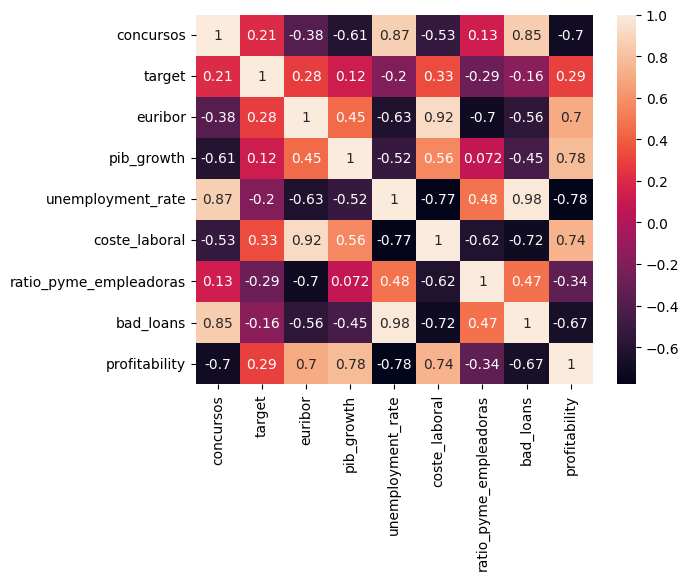

In [ ]:
import seaborn as sns

corr = df_model.drop(columns=["year"]).corr()

sns.heatmap(corr, annot=True)
plt.show()

## OUTLIERS

### Para analizar la distribución de las variables, se ha aplicado una estandarización previa mediante StandardScaler, con el objetivo de homogeneizar las escalas y permitir una comparación adecuada entre variables. El análisis mediante diagramas de caja muestra que variables como la morosidad (bad_loans), el coste laboral y la rentabilidad presentan una mayor dispersión, lo que indica una mayor variabilidad a lo largo del tiempo. Asimismo, se identifican valores atípicos en variables como el número de concursos, el Euribor y el crecimiento del PIB, lo que sugiere la presencia de shocks económicos puntuales que pueden influir significativamente en el comportamiento del sistema.

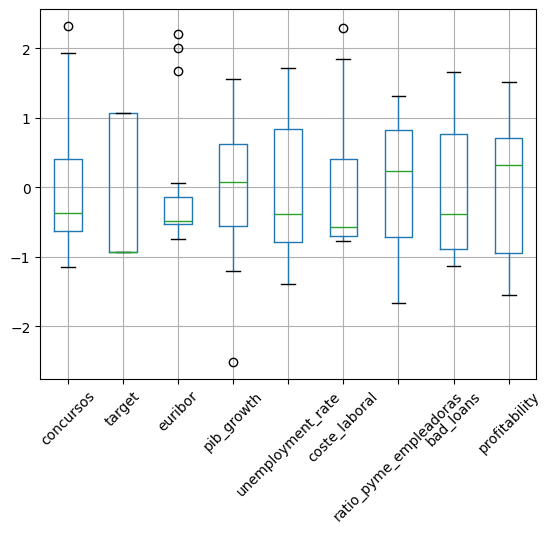

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model.drop(columns=["year"]))
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns.drop("year"))

df_scaled.boxplot()
plt.xticks(rotation=45)
plt.show()

## DISTRIBUCION DEL NUMERO DE CONCURSOSO SEGUN LA VARIABLE OBJETIVO

### Con el objetivo de validar la variable dependiente del modelo, se analiza la distribución del número de concursos en función del valor de la variable objetivo (target). Se observa que los casos etiquetados como target = 1 presentan una mayor dispersión y alcanzan valores más elevados en el número de concursos, lo que indica una mayor inestabilidad económica en dichos periodos. Por el contrario, los casos con target = 0 muestran una distribución más concentrada y valores generalmente inferiores, lo que sugiere un entorno económico más estable. Estos resultados respaldan la coherencia de la variable objetivo, evidenciando que está capturando adecuadamente situaciones de mayor riesgo de insolvencia.

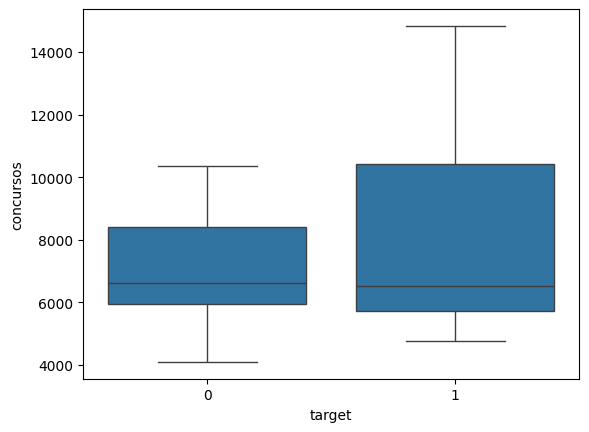

In [114]:
import seaborn as sns

sns.boxplot(x="target", y="concursos", data=df_model)
plt.show()

## ANALISIS DE LA RELACION ENTRE DESEMPLEO Y CONCURSOS EMPRESARIALES

### Con el objetivo de analizar de forma más precisa la relación entre la tasa de desempleo y el número de concursos empresariales, se incorpora una línea de regresión lineal sobre el diagrama de dispersión. Los resultados muestran una clara relación positiva entre ambas variables, evidenciada por la pendiente ascendente de la recta de regresión. Esto indica que, a medida que aumenta la tasa de paro, el número de concursos tiende a incrementarse. Además, la banda de confianza asociada a la regresión sugiere que, aunque existe cierta variabilidad en los datos, la tendencia general es consistente y robusta. Este resultado refuerza la evidencia obtenida previamente en el análisis de correlaciones, confirmando que el desempleo es un factor relevante en la explicación del riesgo de insolvencia empresarial.

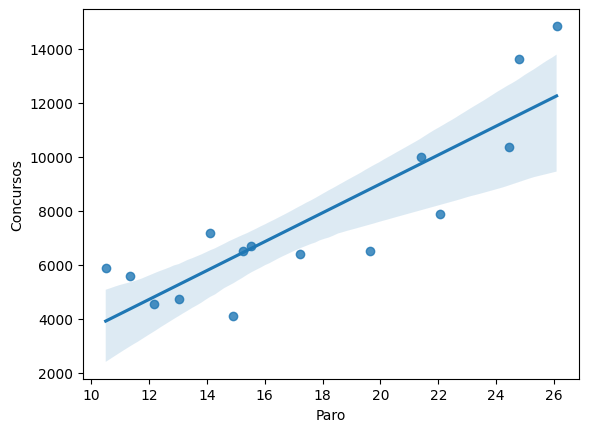

In [116]:
import seaborn as sns

sns.regplot(x="unemployment_rate", y="concursos", data=df_model)
plt.xlabel("Paro")
plt.ylabel("Concursos")
plt.show()

## ANALISIS UNIVARIANTE DE LAS VARIABLES DEL MODELO 

### Se ha analizado la distribución de las variables mediante histogramas con el objetivo de comprender su comportamiento estadístico. Se observa que varias variables presentan distribuciones asimétricas, especialmente en el caso de los concursos y la morosidad, lo que refleja la existencia de episodios económicos extremos como crisis. Por otro lado, variables como el crecimiento del PIB muestran valores tanto positivos como negativos, capturando adecuadamente el ciclo económico. Asimismo, algunas variables como el ratio de pymes empleadoras presentan una variabilidad muy reducida, lo que podría limitar su capacidad explicativa en los modelos. Finalmente, se identifican diferencias importantes en las escalas de las variables, especialmente en la morosidad, lo que justifica la aplicación de técnicas de estandarización en fases posteriores del análisi

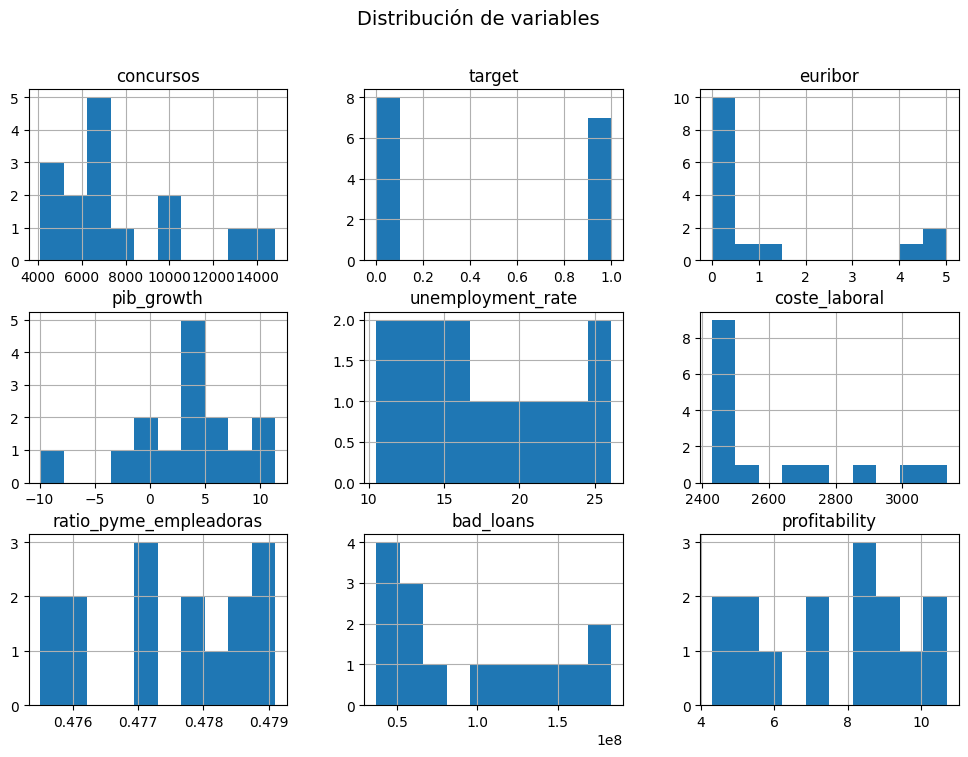

In [117]:
df_model.drop(columns=["year"]).hist(figsize=(12,8))
plt.suptitle("Distribución de variables", fontsize=14)
plt.show()

## DISTRIBUCION DE CLASES DE LA VARIABLE OBJETIVO

### Se analiza la distribución de la variable objetivo con el fin de detectar posibles problemas de desbalanceo en el dataset. Los resultados muestran una distribución prácticamente equilibrada entre ambas clases (0 y 1), lo que indica que no existe un sesgo significativo hacia ninguna de ellas.Este aspecto es especialmente relevante en problemas de clasificación, ya que evita la necesidad de aplicar técnicas adicionales de balanceo (como oversampling o undersampling) y permite utilizar métricas estándar como accuracy, precision, recall o F1-score sin riesgo de interpretaciones sesgadas.

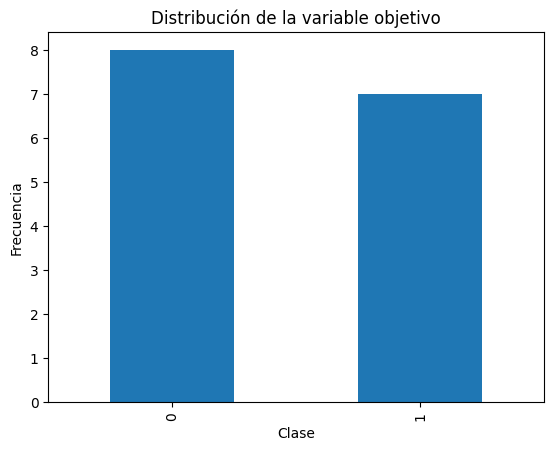

In [118]:
df_model["target"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()